In [1]:
import mmbra
import mmbracategories

import torch
import os
import scipy.io as sio

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import mutual_info_classif

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Code from Google Collab



# load data
data_dir_root = os.path.join('./data', 'ThingsEEG-Text')
sbj = 'sub-10'
image_model = 'pytorch/cornet_s'
text_model = 'CLIPText'
roi = '17channels'

# getting directory and joining that
brain_dir = os.path.join(data_dir_root, 'brain_feature', roi, sbj)
image_dir_seen = os.path.join(data_dir_root, 'visual_feature/ThingsTrain', image_model, sbj)
image_dir_unseen = os.path.join(data_dir_root, 'visual_feature/ThingsTest', image_model, sbj)
text_dir_seen = os.path.join(data_dir_root, 'textual_feature/ThingsTrain/text', text_model, sbj)
text_dir_unseen = os.path.join(data_dir_root, 'textual_feature/ThingsTest/text', text_model, sbj)

# Data Loading

# set up directory by constructing data paths to the data sets
# organizes these paths based on the subject identifier, data type (training or testing), and the model used (e.g., image and text models).
# datasets are loaded from .mat files using the scipy.io.loadmat() function.
# function reads the data into numpy arrays, facilitating data manipulation.


# Data Preprocessing

# For the brain data, specific time intervals are extracted and the data is reshaped to a two-dimensional format to simplify analysis
# Image and text data are scaled to enhance numerical stability during model training
# Dimensionality reduction is applied to the image data to limit the number of features, making the dataset more manageable and reducing computational complexity

# Conversion to PyTorch Tensors

# The numpy arrays for each dataset (brain, image, text, and labels) are converted into PyTorch tensors. 
# This conversion is crucial for efficient data handling in neural network training, as tensors are optimized for operations on GPU.

brain_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['data'].astype('double') * 2.0
brain_seen = brain_seen[:,:,27:60] # 70ms-400ms
brain_seen = np.reshape(brain_seen, (brain_seen.shape[0], -1))
image_seen = sio.loadmat(os.path.join(image_dir_seen, 'feat_pca_train.mat'))['data'].astype('double')*50.0
text_seen = sio.loadmat(os.path.join(text_dir_seen, 'text_feat_train.mat'))['data'].astype('double')*2.0
label_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['class_idx'].T.astype('int')
image_seen = image_seen[:,0:100]

brain_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['data'].astype('double')*2.0
brain_unseen = brain_unseen[:, :, 27:60]
brain_unseen = np.reshape(brain_unseen, (brain_unseen.shape[0], -1))
image_unseen = sio.loadmat(os.path.join(image_dir_unseen, 'feat_pca_test.mat'))['data'].astype('double')*50.0
text_unseen = sio.loadmat(os.path.join(text_dir_unseen, 'text_feat_test.mat'))['data'].astype('double')*2.0
label_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['class_idx'].T.astype('int')
image_unseen = image_unseen[:, 0:100]

brain_seen = torch.from_numpy(brain_seen)
brain_unseen = torch.from_numpy(brain_unseen)
image_seen = torch.from_numpy(image_seen)
image_unseen = torch.from_numpy(image_unseen)
text_seen = torch.from_numpy(text_seen)
text_unseen = torch.from_numpy(text_unseen)
label_seen = torch.from_numpy(label_seen)
label_unseen = torch.from_numpy(label_unseen)

# Summary 

# The code prints the shape of each dataset, providing an overview of the number of samples and features for both training and testing sets. 
# This summary helps confirm that the data is correctly formatted and that the expected number of features is present. 
# This process of data loading, preprocessing, and conversion into PyTorch tensors ensures that the brain, image, and text datasets are ready for further analysis or machine learning tasks.

print('seen_brain_samples=', brain_seen.shape[0], ', seen_brain_features=', brain_seen.shape[1])
print('seen_image_samples=', image_seen.shape[0], ', seen_image_features=', image_seen.shape[1])
print('seen_text_samples=', text_seen.shape[0], ', seen_text_features=', text_seen.shape[1])
print('seen_label=', label_seen.shape)
print('unseen_brain_samples=', brain_unseen.shape[0], ', unseen_brain_features=', brain_unseen.shape[1])
print('unseen_image_samples=', image_unseen.shape[0], ', unseen_image_features=', image_unseen.shape[1])
print('unseen_text_samples=', text_unseen.shape[0], ', unseen_text_features=', text_unseen.shape[1])
print('unseen_label=', label_unseen.shape)

seen_brain_samples= 16540 , seen_brain_features= 561
seen_image_samples= 16540 , seen_image_features= 100
seen_text_samples= 16540 , seen_text_features= 512
seen_label= torch.Size([16540, 1])
unseen_brain_samples= 16000 , unseen_brain_features= 561
unseen_image_samples= 16000 , unseen_image_features= 100
unseen_text_samples= 16000 , unseen_text_features= 512
unseen_label= torch.Size([16000, 1])


In [3]:
# Summary Statistics

#Convert data into Pandas Dataframe for easier exploration and anaylsis.
mmbra.data_analysis_example(brain_seen, image_seen, text_seen)

Brain data summary statistics:
                0             1             2             3             4    \
count  16540.000000  16540.000000  16540.000000  16540.000000  16540.000000   
mean       0.076787      0.070698      0.028373     -0.044438     -0.067034   
std        0.583893      0.592233      0.610593      0.630831      0.641200   
min       -2.762807     -2.598095     -2.349412     -2.818633     -3.008686   
25%       -0.309925     -0.320417     -0.378459     -0.459167     -0.493376   
50%        0.072401      0.068746      0.033988     -0.046756     -0.061193   
75%        0.464845      0.459148      0.433262      0.374403      0.357285   
max        2.293334      2.570706      2.949977      2.507507      2.499492   

                5             6             7             8             9    \
count  16540.000000  16540.000000  16540.000000  16540.000000  16540.000000   
mean      -0.127158     -0.140791     -0.122330     -0.069163     -0.012199   
std        0.646158 

In [4]:
#TEXT_SEEN
text_seen_df = pd.DataFrame(text_seen.numpy())  # Convert PyTorch tensor to DataFrame if needed

# Calculate variance for each feature (column-wise)
text_variance = text_seen_df.var()

# Display variance for the first 10 features
print("Feature-wise Variance:")
print(text_variance)

print("max variance:", text_variance.max())
print("min variance:", text_variance.min())

Feature-wise Variance:
0      0.183067
1      0.221548
2      0.188008
3      0.178828
4      0.212255
         ...   
507    0.222826
508    0.193755
509    0.244454
510    0.209132
511    0.275796
Length: 512, dtype: float64
max variance: 2.7887389949409584
min variance: 0.0684934324423655


In [5]:
text_seen_df

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
0,-1.051765,-0.188069,-0.595092,-0.106280,-0.000042,0.259468,-0.824246,-1.074296,0.100001,0.452961,...,0.079456,0.850631,-0.411319,0.273861,-0.207523,0.588601,0.336931,0.547759,-0.067409,-0.228423
1,-0.791820,0.722638,-0.750893,0.604263,-0.096118,-0.180995,-0.107345,-1.378767,0.089730,0.755525,...,-0.125149,0.493041,-0.111407,-0.047574,-0.712646,0.230033,0.605654,-0.090307,-1.181282,-1.126687
2,-0.655546,-0.335914,-1.071692,0.533285,-0.043359,0.137325,0.269942,-1.501647,-1.331311,-0.012337,...,-0.143885,-0.042760,0.050774,0.037872,-0.212290,-0.189082,-0.028609,-0.157924,-0.090286,0.890664
3,0.053093,-0.368174,0.087328,0.263806,0.739228,-0.116403,-0.232868,-0.883717,-0.983919,0.725002,...,0.407825,-0.100994,0.504711,0.125284,-0.154703,0.243986,0.879884,0.832958,-0.783952,0.296747
4,-0.698951,0.777568,-0.961129,0.507661,-0.686843,-0.570301,-0.339451,-1.376515,0.448556,0.833378,...,-0.239638,-0.312372,-0.206590,-0.470965,-0.890891,0.627109,0.583367,-0.306033,-1.323599,-0.660871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16535,0.007359,0.330990,-0.109946,0.965443,0.319409,0.221264,-0.571042,-0.898793,-0.177655,-0.355348,...,0.021251,0.321158,1.314686,-0.033611,0.466383,0.017770,0.771485,0.879974,0.435717,0.118892
16536,-0.019379,0.363706,-0.173224,0.342036,-0.317965,-0.221702,-0.720118,-0.571327,-0.515076,-0.025434,...,0.027085,0.536973,0.738799,-0.680310,0.428624,0.130700,0.826870,0.627625,0.188157,-0.506750
16537,0.109753,-0.224811,0.327096,0.296766,0.541646,-0.429739,-0.764535,-0.779763,-1.181712,-0.381626,...,0.389855,0.735086,1.616888,-0.454523,0.022289,0.084762,0.875400,0.498001,0.072932,-0.246190
16538,0.256283,-0.238174,0.041500,0.213213,-0.103968,-0.189265,-1.509183,0.059570,-0.624174,-0.641180,...,0.412517,0.397894,1.246133,-0.746328,0.518797,0.060195,0.600754,1.565386,0.003159,-0.246933


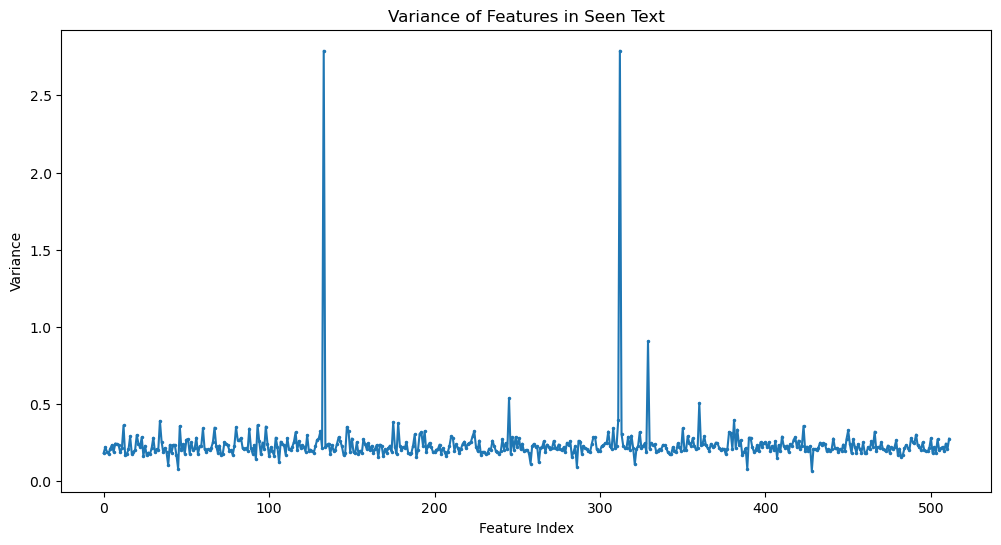

In [6]:
# Plot feature variances
plt.figure(figsize=(12, 6))
text_variance.plot(kind='line', marker='.', linestyle='-', markersize=3)
plt.xlabel("Feature Index")
plt.ylabel("Variance")
plt.title("Variance of Features in Seen Text")
plt.show()

In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize LDA
lda = LinearDiscriminantAnalysis()
reduced_data = lda.fit_transform(text_seen_df, label_seen)

/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [8]:
# Convert PyTorch tensor to NumPy if needed
seen_label_np = label_seen.numpy().ravel()  # Replace with your actual label variable

In [9]:
#MAKING MIC to find top 20 columns

# Compute mutual information between PCA components and labels
mi_scores = mutual_info_classif(reduced_data, seen_label_np)

# Create a DataFrame for easier interpretation
mi_df = pd.DataFrame({'Feature': [f'LD{i+1}' for i in range(reduced_data.shape[1])], 'MI Score': mi_scores})

# Sort features by MI score
mi_df = mi_df.sort_values(by='MI Score', ascending=False)
print(mi_df)

    Feature  MI Score
0       LD1  1.614455
2       LD3  1.457228
3       LD4  1.441972
4       LD5  1.410802
1       LD2  1.395207
..      ...       ...
503   LD504  0.306229
504   LD505  0.305060
502   LD503  0.302180
499   LD500  0.297186
508   LD509  0.286254

[511 rows x 2 columns]


In [10]:
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# import numpy as np

# # Define quartile colors
# colors = ['#36669c', '#41a0ae', '#3ec995', '#77f07f']  # Colors for each quartile

# # Determine quartile ranges
# num_features = len(mi_df['Feature'])
# quartile_size = num_features // 4  # Number of features per quartile

# # Assign colors to bars based on their quartile
# bar_colors = []
# for i in range(num_features):
#     if i < quartile_size:
#         bar_colors.append(colors[0])  # First quartile
#     elif i < quartile_size * 2:
#         bar_colors.append(colors[1])  # Second quartile
#     elif i < quartile_size * 3:
#         bar_colors.append(colors[2])  # Third quartile
#     else:
#         bar_colors.append(colors[3])  # Fourth quartile

# # Plot the data
# plt.figure(figsize=(18, 10))
# plt.bar(mi_df['Feature'], mi_df['MI Score'], color=bar_colors, alpha=0.8)

# # Add axis labels and title
# plt.xticks(rotation=45, ha='right', fontsize=10)
# plt.title('Mutual Information Scores for LDA Components', fontsize=14)
# plt.xlabel('LDA Components', fontsize=12)
# plt.ylabel('Mutual Information Score', fontsize=12)

# # Add a legend to explain quartiles
# legend_labels = ['First Quartile (0-25%)', 'Second Quartile (26-50%)', 'Third Quartile (51-75%)', 'Fourth Quartile (76-100%)']
# legend_patches = [mpatches.Patch(color=colors[i], label=legend_labels[i]) for i in range(4)]
# plt.legend(handles=legend_patches, title="X-axis Quartiles", fontsize=10)

# # Improve layout
# plt.tight_layout()
# plt.show()

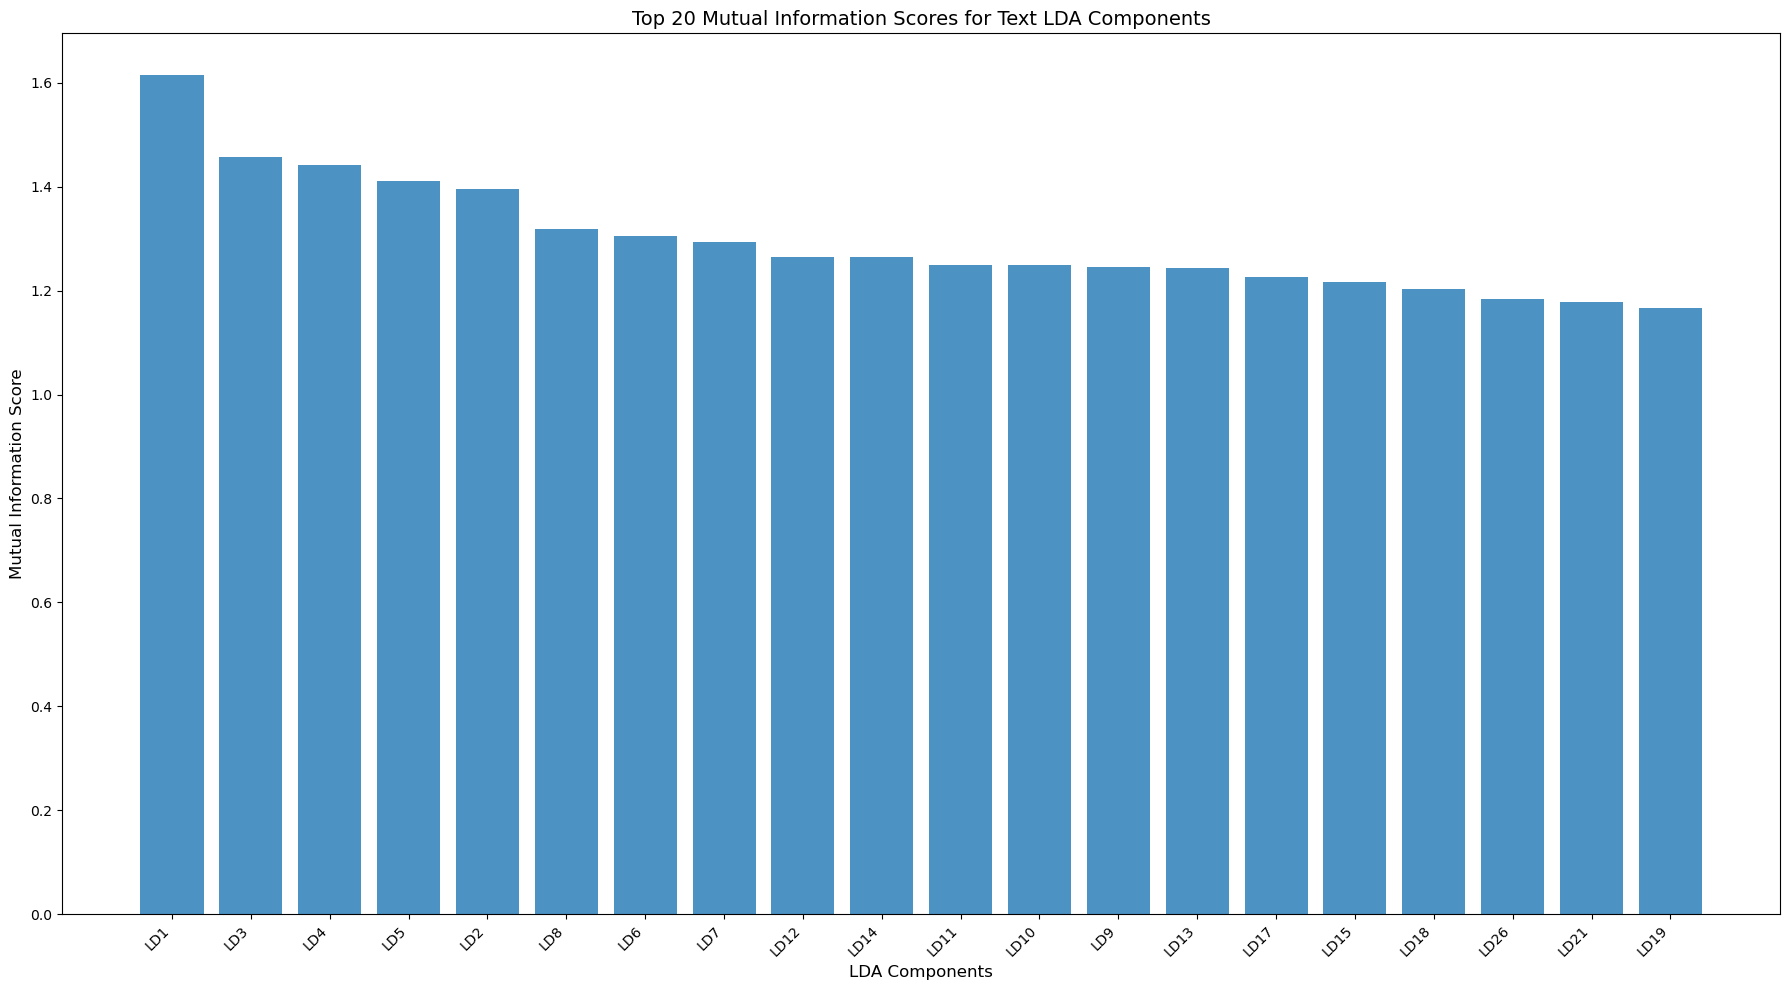

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Assuming mi_df is your DataFrame with 'Feature' and 'MI Score' columns
# Sort the DataFrame by 'MI Score' in descending order and select the top 20 features
mi_df = mi_df.sort_values(by='MI Score', ascending=False).head(20)

# Define quartile colors
colors = ['#36669c', '#41a0ae', '#3ec995', '#77f07f']  # Colors for each quartile

# Determine quartile ranges for the top 20 features
num_features = len(mi_df['Feature'])
quartile_size = num_features // 4  # Number of features per quartile

# # Assign colors to bars based on their quartile
# bar_colors = []
# for i in range(num_features):
#     if i < quartile_size:
#         bar_colors.append(colors[0])  # First quartile
#     elif i < quartile_size * 2:
#         bar_colors.append(colors[1])  # Second quartile
#     elif i < quartile_size * 3:
#         bar_colors.append(colors[2])  # Third quartile
#     else:
#         bar_colors.append(colors[3])  # Fourth quartile

# Plot the data
plt.figure(figsize=(18, 10))
plt.bar(mi_df['Feature'], mi_df['MI Score'], alpha=0.8)
# plt.bar(mi_df['Feature'], mi_df['MI Score'], color=bar_colors, alpha=0.8)
# Add axis labels and title
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Top 20 Mutual Information Scores for Text LDA Components', fontsize=14)
plt.xlabel('LDA Components', fontsize=12)
plt.ylabel('Mutual Information Score', fontsize=12)

# # Add a legend to explain quartiles
# legend_labels = ['First Quartile (0-25%)', 'Second Quartile (26-50%)', 'Third Quartile (51-75%)', 'Fourth Quartile (76-100%)']
# legend_patches = [mpatches.Patch(color=colors[i], label=legend_labels[i]) for i in range(4)]
# plt.legend(handles=legend_patches, title="X-axis Quartiles", fontsize=10)

# Improve layout
plt.tight_layout()
plt.show()

In [12]:
# Threshold and selected components
threshold = np.percentile(mi_scores, 75)
selected_components = np.where(mi_scores > threshold)[0]
print(f"Selected PCA components: {selected_components}")

# Filter the PCA-transformed dataset using these indices
text_selected_components_data = reduced_data[:, selected_components]
print(f"Filtered Data Shape: {text_selected_components_data.shape}")

Selected PCA components: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 130 131]
Filtered Data Shape: (16540, 128)


In [13]:
text_selected_components_data = torch.from_numpy(text_selected_components_data)

In [14]:
#Use 20 categories
index_seen = np.squeeze(np.where(label_seen < 21, True, False))
index_unseen = np.squeeze(np.where(label_unseen < 21, True, False))

brain_seen = brain_seen[index_seen, :]
image_seen = image_seen[index_seen, :]
text_seen = text_selected_components_data[index_seen, :]
label_seen = label_seen[index_seen]
brain_unseen = brain_unseen[index_unseen, :]
image_unseen = image_unseen[index_unseen, :]
text_unseen = text_unseen[index_unseen, :]
label_unseen = label_unseen[index_unseen]

#The ThingsEEG-Text dataset is mainly designed and used for Zero-Shot type research work, because the independence of its training set and test set
#in categories is very suitable for this task. If it needs to be used for other types of tasks
#(such as general classification or cross-modal learning),
#the data may need to be repartitioned. Therefore, we repartition the dataset to make it better for our task
#Define the number of classes and the number of samples per class
num_classes = 20
samples_per_class = 10

import torch
#For each class, take the first 5 images as training and the last 5 images as testing
new_train_brain = []
new_train_image = []
new_train_text = []
new_train_label = []

new_test_brain = []
new_test_image = []
new_test_text = []
new_test_label = []

# Convert numpy arrays to PyTorch tensors before appending
for i in range(num_classes):
    start_idx = i * samples_per_class  # The starting index of the current class
    end_idx = start_idx + samples_per_class  # The end index of the current class

    # Get the data of the current class
    class_data_brain = torch.tensor(brain_seen[start_idx:end_idx, :])  # Convert to tensor
    new_train_brain.append(class_data_brain[:7])
    new_test_brain.append(class_data_brain[7:])

    class_data_image = torch.tensor(image_seen[start_idx:end_idx, :])  # Convert to tensor
    new_train_image.append(class_data_image[:7])
    new_test_image.append(class_data_image[7:])

    class_data_text = torch.tensor(text_seen[start_idx:end_idx, :])  # Convert to tensor
    new_train_text.append(class_data_text[:7])
    new_test_text.append(class_data_text[7:])

    class_data_label = torch.tensor(label_seen[start_idx:end_idx, :])  # Convert to tensor
    new_train_label.append(class_data_label[:7])
    new_test_label.append(class_data_label[7:])

# Stack the tensors
train_brain = torch.vstack(new_train_brain)
train_image = torch.vstack(new_train_image)
train_text = torch.vstack(new_train_text)
train_label = torch.vstack(new_train_label)
test_brain = torch.vstack(new_test_brain)
test_image = torch.vstack(new_test_image)
test_text = torch.vstack(new_test_text)
test_label = torch.vstack(new_test_label)

# Print shapes
print(train_brain.shape)
print(train_image.shape)
print(train_text.shape)
print(train_label.shape)
print(test_brain.shape)
print(test_image.shape)
print(test_text.shape)
print(test_label.shape)

torch.Size([140, 561])
torch.Size([140, 100])
torch.Size([140, 128])
torch.Size([140, 1])
torch.Size([60, 561])
torch.Size([60, 100])
torch.Size([60, 128])
torch.Size([60, 1])


/var/folders/63/sts5pq893c76k079c87fr3s40000gn/T/ipykernel_39035/1563826941.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_data_brain = torch.tensor(brain_seen[start_idx:end_idx, :])  # Convert to tensor
/var/folders/63/sts5pq893c76k079c87fr3s40000gn/T/ipykernel_39035/1563826941.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_data_image = torch.tensor(image_seen[start_idx:end_idx, :])  # Convert to tensor
/var/folders/63/sts5pq893c76k079c87fr3s40000gn/T/ipykernel_39035/1563826941.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(

In [15]:
# Train a model using the reduced feature set
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Step 1: Train a Random Forest Classifier on the reduced training set
clf = RandomForestClassifier(n_estimators=49)
clf.fit(train_text, train_label)

# Step 2: Make predictions on the test set
pred_text = clf.predict(test_text)

# Step 3: Evaluate the model
accuracy = accuracy_score(test_label, pred_text)
print(f"Test Set Accuracy: {accuracy:.2f}")

Test Set Accuracy: 0.93


/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Initialize KNN model 14
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(train_text, train_label)

pred_text = knn.predict(test_text)

accuracy = accuracy_score(test_label, pred_text)
print(f"Test Set Accuracy: {accuracy:.2f}")

Test Set Accuracy: 0.97


/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel='linear')
svm.fit(train_text, train_label)

pred_text = svm.predict(test_text)

accuracy = accuracy_score(test_label, pred_text)
print(f"Test Set Accuracy: {accuracy:.2f}")

Test Set Accuracy: 0.97


/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [18]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize the SVM model
# You can experiment with different kernels: 'linear', 'rbf', 'poly', or 'sigmoid'
svm_model = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)

# 2. Train the SVM model on the training data
svm_model.fit(train_text, train_label)

# 3. Make predictions on the test data
pred_text = svm_model.predict(test_text)

# 4. Evaluate the model
print("Accuracy on Test Data:", accuracy_score(test_label, pred_text))

Accuracy on Test Data: 0.95


/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
